# DeepLabV3+ для сегментации нефтяных разливов на SAR-снимках Sentinel-1

## Установка зависимостей

In [1]:
import subprocess, sys

subprocess.run([
    sys.executable, "-m", "pip", "install",
    "rasterio",
    "albumentations==2.0.8",
    "segmentation-models-pytorch",
    "optuna",
    "-q"
], check=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'rasterio', 'albumentations==2.0.8', 'segmentation-models-pytorch', 'optuna', '-q'], returncode=0)

## Конфигурация и фиксация seed

In [2]:
import os, gc, json, random, warnings, base64
from pathlib import Path
from IPython.display import HTML, display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import rasterio
from rasterio.windows import Window

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp
from tqdm.notebook import tqdm
import optuna
from optuna.samplers import TPESampler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [3]:
# ── Seed ──────────────────────────────────────────────────────────────────────
SEED = 42

def set_seed(seed: int):
    """Фиксирует все источники случайности. Вызывается перед каждым этапом."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
    os.environ["PYTHONHASHSEED"]       = str(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Устройство: {DEVICE}")

Устройство: cuda


In [4]:
# ── Пути ──────────────────────────────────────────────────────────────────────
BASE = Path("/kaggle/input")

OIL_IMG_DIR      = BASE / "datasets/daryanikitina/sar-oil-spill-part1" / "Oil"
OIL_MASK_DIR     = BASE / "datasets/daryanikitina/sar-oil-spill-part1" / "Mask_oil"
NO_OIL_IMG_DIR   = BASE / "datasets/daryanikitina/sar-oil-spill-part2" / "No_oil"
NO_OIL_MASK_DIR  = BASE / "datasets/daryanikitina/sar-oil-spill-part2" / "Mask_no_oil"
LOOK_IMG_DIR     = BASE / "datasets/daryanikitina/sar-oil-spill-part2" / "Lookalike"
LOOK_MASK_DIR    = BASE / "datasets/daryanikitina/sar-oil-spill-part2" / "Mask_lookalike"
TEST_BASE        = BASE / "datasets/daryanikitina/sar-oil-spill-part3"
TEST_IMG_DIR     = TEST_BASE / "Images"
TEST_MASK_DIR    = TEST_BASE / "Mask"
TEST_CLASSES     = ["Oil", "No oil", "Lookalike"]

CONFIG_DIR = BASE / "datasets/zhanslubabieva/dl-final-project"
OUTPUT     = Path("/kaggle/working")
OUTPUT.mkdir(parents=True, exist_ok=True)

print("Проверка данных:")
for name, p in [
    ("Oil images",            OIL_IMG_DIR),
    ("Oil masks",             OIL_MASK_DIR),
    ("No-oil images",         NO_OIL_IMG_DIR),
    ("Lookalike images",      LOOK_IMG_DIR),
    ("No-oil masks",          NO_OIL_MASK_DIR),
    ("Lookalike masks",       LOOK_MASK_DIR),
    ("Test images Oil",       TEST_IMG_DIR / "Oil"),
    ("Test images No-oil",    TEST_IMG_DIR / "No oil"),
    ("Test images Lookalike", TEST_IMG_DIR / "Lookalike"),
    ("Test masks Oil",        TEST_MASK_DIR / "Oil"),
    ("Test masks No-oil",     TEST_MASK_DIR / "No oil"),
    ("Test masks Lookalike",  TEST_MASK_DIR / "Lookalike"),
]:
    n = len(list(p.glob("*.tif"))) if p.exists() else 0
    print(f"  [{'OK' if n>0 else 'НЕ НАЙДЕНО'}]  {name:25s}: {n} файлов")

Проверка данных:
  [OK]  Oil images               : 1200 файлов
  [OK]  Oil masks                : 1200 файлов
  [OK]  No-oil images            : 685 файлов
  [OK]  Lookalike images         : 685 файлов
  [OK]  No-oil masks             : 685 файлов
  [OK]  Lookalike masks          : 685 файлов
  [OK]  Test images Oil          : 150 файлов
  [OK]  Test images No-oil       : 150 файлов
  [OK]  Test images Lookalike    : 150 файлов
  [OK]  Test masks Oil           : 150 файлов
  [OK]  Test masks No-oil        : 150 файлов
  [OK]  Test masks Lookalike     : 150 файлов


## Загрузка общих параметров команды

Зафиксированы в `shared_config.json`. Не меняем их

In [5]:
with open(CONFIG_DIR / "shared_config.json") as f:
    CFG = json.load(f)

PATCH_SIZE       = CFG["PATCH_SIZE"]
VV_MEAN          = CFG["norm_stats"]["VV_mean"]
VV_STD           = CFG["norm_stats"]["VV_std"]
VH_MEAN          = CFG["norm_stats"]["VH_mean"]
VH_STD           = CFG["norm_stats"]["VH_std"]
OVERSAMPLE_RATIO = CFG["OVERSAMPLE_RATIO"]
BCE_WEIGHT       = CFG["BEST_LOSS_PARAMS"]["bce_weight"]
POS_WEIGHT_VAL   = CFG["BEST_LOSS_PARAMS"]["pos_weight"]

# Архитектурные константы
ENCODER         = "resnet34"
ENCODER_WEIGHTS = "imagenet"
NUM_CLASSES     = 1
IN_CHANNELS     = 2            # SAR: VV + VH

BATCH_SIZE       = 8
SELECTION_WINDOW = 3

print("Параметры из shared_config.json:")
print(f"  PATCH_SIZE:    {PATCH_SIZE}")
print(f"  VV mean/std:   {VV_MEAN} / {VV_STD}")
print(f"  VH mean/std:   {VH_MEAN} / {VH_STD}")
print(f"  Oversampling:  {OVERSAMPLE_RATIO}")
print(f"  Loss:          {CFG['BEST_LOSS']}  "
      f"(bce_weight={BCE_WEIGHT:.4f}, pos_weight={POS_WEIGHT_VAL:.4f})")

Параметры из shared_config.json:
  PATCH_SIZE:    512
  VV mean/std:   -31.315275 / 7.87874
  VH mean/std:   -19.719892 / 6.16873
  Oversampling:  1:1
  Loss:          bce_dice  (bce_weight=0.6392, pos_weight=22.9598)


## Dataset и DataLoader

In [6]:
def load_patch(img_path, mask_path, row, col, patch_size):
    """Загружает патч patch_size×patch_size через Window API rasterio (без загрузки всего снимка)."""
    win = Window(col, row, patch_size, patch_size)
    with rasterio.open(img_path) as src:
        img = src.read(window=win).astype(np.float32)
    with rasterio.open(mask_path) as src:
        mask = src.read(1, window=win).astype(np.uint8)
    _, h, w = img.shape
    if h < patch_size or w < patch_size:
        pi = np.zeros((2, patch_size, patch_size), dtype=np.float32)
        pm = np.zeros((patch_size, patch_size), dtype=np.uint8)
        pi[:, :h, :w] = img; pm[:h, :w] = mask
        img, mask = pi, pm
    return np.transpose(img, (1, 2, 0)), mask


def normalize_patch(img, vv_mean, vv_std, vh_mean, vh_std):
    """Z-score нормализация по каждому каналу. Статистика только из train (нет data leakage)."""
    img = img.copy()
    img[:, :, 0] = (img[:, :, 0] - vv_mean) / (vv_std + 1e-8)
    img[:, :, 1] = (img[:, :, 1] - vh_mean) / (vh_std + 1e-8)
    return img

In [7]:
class SARPatchDataset(Dataset):
    """
    Датасет патчей SAR-снимков.
    Оверсэмплинг 1:1 — только для train: нефтяных патчей = фоновых.
    """
    def __init__(self, inventory_df, oversample_ratio="1:1",
                 transform=None, is_train=True, seed=SEED):
        self.df        = inventory_df.reset_index(drop=True)
        self.transform = transform
        self.patch_size= PATCH_SIZE

        if is_train and oversample_ratio == "1:1":
            oil_df = self.df[self.df["has_oil"] == 1]
            bg_df  = self.df[self.df["has_oil"] == 0]
            n_oil  = len(oil_df)
            bg_sampled = bg_df.sample(n=n_oil, random_state=seed, replace=True)
            rng = np.random.default_rng(seed)
            oil_idx = rng.choice(len(oil_df), size=len(bg_sampled),
                                 replace=(n_oil < len(bg_sampled)))
            oil_sampled = oil_df.iloc[oil_idx]
            self.df = (
                pd.concat([oil_sampled, bg_sampled], ignore_index=True)
                .sample(frac=1, random_state=seed)
                .reset_index(drop=True)
            )
            print(f"  Оверсэмплинг 1:1: нефть={len(oil_sampled)}, "
                  f"фон={len(bg_sampled)}, итого={len(self.df)}")
        else:
            print(f"  Без оверсэмплинга: {len(self.df)} патчей")

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img, mask = load_patch(r["image_path"], r["mask_path"],
                               int(r["row"]), int(r["col"]), self.patch_size)
        img = normalize_patch(img, VV_MEAN, VV_STD, VH_MEAN, VH_STD)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        else:
            img  = torch.tensor(img.transpose(2,0,1), dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.long)
        return img, mask.float()

In [8]:
class SARTestDataset(Dataset):
    """Датасет тестовых снимков. Нарезка на патчи на лету по подпапкам классов."""
    def __init__(self, img_dir, mask_dir, classes, transform=None):
        self.transform = transform
        records = []
        for cls in classes:
            cid = img_dir / cls
            cmd = mask_dir / cls
            if not cid.exists():
                print(f"  [!] Не найдено: {cid}"); continue
            for img_f in sorted(cid.glob("*.tif")):
                mask_f = cmd / f"{img_f.stem}_segmentation.tif"
                if not mask_f.exists():
                    mask_f = cmd / img_f.name
                if not mask_f.exists(): continue
                with rasterio.open(img_f) as src:
                    H, W = src.height, src.width
                for r in range(0, H, PATCH_SIZE):
                    for c in range(0, W, PATCH_SIZE):
                        records.append({"image_path": str(img_f),
                                        "mask_path":  str(mask_f),
                                        "row": r, "col": c,
                                        "cls": cls, "filename": img_f.name})
        self.df = pd.DataFrame(records)
        print(f"  Тест: {len(self.df):,} патчей")
        if len(self.df) > 0:
            print(self.df.groupby("cls")["filename"].nunique().rename("снимков").to_string())

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        r = self.df.iloc[idx]
        img, mask = load_patch(r["image_path"], r["mask_path"],
                               int(r["row"]), int(r["col"]), PATCH_SIZE)
        img = normalize_patch(img, VV_MEAN, VV_STD, VH_MEAN, VH_STD)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug["image"], aug["mask"]
        else:
            img  = torch.tensor(img.transpose(2,0,1), dtype=torch.float32)
            mask = torch.tensor(mask, dtype=torch.long)
        return img, mask.float(), r["filename"]

In [9]:
transform_base = A.Compose([ToTensorV2()])  # aug_v1: без аугментаций

def worker_init_fn(worker_id):
    np.random.seed(SEED + worker_id)
    random.seed(SEED + worker_id)

print("Загружаем инвентари патчей...")
train_inv = pd.read_csv(CONFIG_DIR / "train_patch_inventory.csv")
val_inv   = pd.read_csv(CONFIG_DIR / "val_patch_inventory.csv")
print(f"  Train: {len(train_inv):,} патчей  "
      f"(нефть: {train_inv['has_oil'].sum():,}, фон: {(train_inv['has_oil']==0).sum():,})")
print(f"  Val:   {len(val_inv):,} патчей  "
      f"(нефть: {val_inv['has_oil'].sum():,}, фон: {(val_inv['has_oil']==0).sum():,})")

print("\nСоздаем датасеты...")
train_dataset = SARPatchDataset(train_inv, OVERSAMPLE_RATIO, transform_base, is_train=True)
val_dataset   = SARPatchDataset(val_inv,   None,             transform_base, is_train=False)

def make_loaders(train_ds, val_ds, batch_size=BATCH_SIZE):
    tl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                    num_workers=2, pin_memory=True, worker_init_fn=worker_init_fn)
    vl = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                    num_workers=2, pin_memory=True, worker_init_fn=worker_init_fn)
    return tl, vl

train_loader, val_loader = make_loaders(train_dataset, val_dataset)
print(f"\nTrain: {len(train_loader)} батчей | Val: {len(val_loader)} батчей")

print("\nСоздаем тестовый датасет...")
test_dataset = SARTestDataset(TEST_IMG_DIR, TEST_MASK_DIR, TEST_CLASSES, transform_base)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
print(f"  Test: {len(test_loader)} батчей")

Загружаем инвентари патчей...
  Train: 32,896 патчей  (нефть: 5,808, фон: 27,088)
  Val:   8,224 патчей  (нефть: 1,436, фон: 6,788)

Создаем датасеты...
  Оверсэмплинг 1:1: нефть=5808, фон=5808, итого=11616
  Без оверсэмплинга: 8224 патчей

Train: 1452 батчей | Val: 1028 батчей

Создаем тестовый датасет...
  Тест: 7,200 патчей
cls
Lookalike    150
No oil       150
Oil          150
  Test: 900 батчей


## Архитектура DeepLabV3+

In [10]:
def build_model():
    """
    DeepLabV3+ с ResNet-34, адаптированным под 2-канальный SAR-вход.
    SMP автоматически перестраивает первый слой conv1
    """
    return smp.DeepLabV3Plus(
        encoder_name=ENCODER,
        encoder_weights=ENCODER_WEIGHTS,
        in_channels=IN_CHANNELS,
        classes=NUM_CLASSES,
        activation=None,
    )


_m = build_model().to(DEVICE)
total_p = sum(p.numel() for p in _m.parameters())
print(f"DeepLabV3+ (ResNet-34): {total_p:,} параметров")
with torch.no_grad():
    _d = torch.zeros(2, IN_CHANNELS, PATCH_SIZE, PATCH_SIZE).to(DEVICE)
    _o = _m(_d)
    assert _o.shape == (2, 1, PATCH_SIZE, PATCH_SIZE)
    print(f"  Прямой проход: {list(_d.shape)} → {list(_o.shape)}  ОК")
del _m, _d, _o; gc.collect(); torch.cuda.empty_cache()

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

DeepLabV3+ (ResNet-34): 22,434,321 параметров
  Прямой проход: [2, 2, 512, 512] → [2, 1, 512, 512]  ОК


## Loss-функция: BCE + Dice

Параметры из `shared_config.json`. Не меняем.

In [11]:
class BCEDiceLoss(nn.Module):
    """
    loss = bce_weight * BCE(pred, target) + (1 - bce_weight) * Dice(pred, target)
    pos_weight компенсирует дисбаланс нефть:фон ≈ 1:19.
    """
    def __init__(self, bce_weight=BCE_WEIGHT, pos_weight=POS_WEIGHT_VAL, smooth=1.0):
        super().__init__()
        self.bce_weight = bce_weight
        self.smooth     = smooth
        self.register_buffer("pw", torch.tensor([pos_weight], dtype=torch.float32))

    # ── 7. BCEDiceLoss: reshape вместо view + NaN guard ──────────────────────────
    def forward(self, logits, targets):
        lf  = logits.squeeze(1)
        bce = F.binary_cross_entropy_with_logits(
            lf, targets, pos_weight=self.pw.to(logits.device))
        p   = torch.sigmoid(lf)
        pf  = p.reshape(-1); tf = targets.reshape(-1)   # reshape безопаснее view
        dice = 1.0 - (2.0*(pf*tf).sum() + self.smooth) / (pf.sum() + tf.sum() + self.smooth)
        loss = self.bce_weight * bce + (1 - self.bce_weight) * dice
        # NaN guard — помогает поймать взрывной градиент на ранних эпохах
        if torch.isnan(loss):
            print(f"  [WARNING] NaN в loss! bce={bce.item():.4f} dice={dice.item():.4f}")
            return bce  # fallback
        return loss
    
criterion = BCEDiceLoss()
print(f"Loss: BCEDice(bce_weight={BCE_WEIGHT:.4f}, pos_weight={POS_WEIGHT_VAL:.4f})")

Loss: BCEDice(bce_weight=0.6392, pos_weight=22.9598)


## Метрики и вспомогательные функции

In [12]:
def compute_iou_per_class(preds_bin, targets, smooth=1e-6):
    """IoU по каждому классу"""
    pb = preds_bin.long(); t = targets.long()
    oil_i  = ((pb==1)&(t==1)).float().sum(); oil_u  = ((pb==1)|(t==1)).float().sum()
    bg_i   = ((pb==0)&(t==0)).float().sum(); bg_u   = ((pb==0)|(t==0)).float().sum()
    oil_iou = (oil_i+smooth)/(oil_u+smooth)
    bg_iou  = (bg_i +smooth)/(bg_u +smooth)
    return oil_iou.item(), bg_iou.item(), ((oil_iou+bg_iou)/2).item()


def compute_oil_dice(preds_bin, targets, smooth=1e-6):
    """
    Dice по классу нефти
    Dice = 2*TP / (2*TP + FP + FN)
    """
    pb = preds_bin.long(); t = targets.long()
    tp = ((pb==1)&(t==1)).float().sum()
    fp = ((pb==1)&(t==0)).float().sum()
    fn = ((pb==0)&(t==1)).float().sum()
    return ((2*tp+smooth)/(2*tp+fp+fn+smooth)).item()


@torch.no_grad()
def evaluate(model, loader, criterion, threshold=0.5):
    """Patch-level оценка: loss, IoU по классам, Dice по нефти."""
    model.eval()
    tot_loss, oil_ious, bg_ious, mean_ious, oil_dices = 0., [], [], [], []
    for batch in loader:
        imgs, masks = (batch[0], batch[1])
        imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
        logits = model(imgs)
        tot_loss += criterion(logits, masks).item()
        preds = (torch.sigmoid(logits.squeeze(1)) >= threshold).long()
        oi, bi, mi = compute_iou_per_class(preds, masks.long())
        oil_ious.append(oi); bg_ious.append(bi)
        mean_ious.append(mi); oil_dices.append(compute_oil_dice(preds, masks.long()))
    return {"loss":           tot_loss/len(loader),
            "oil_iou":        np.mean(oil_ious),
            "background_iou": np.mean(bg_ious),
            "mean_iou":       np.mean(mean_ious),
            "oil_dice":       np.mean(oil_dices)}


@torch.no_grad()
def evaluate_scene_level(model, inventory_df, threshold=0.5, smooth=1e-6):
    """
    Scene-level оценка
    """
    model.eval()
    scene_ious, scene_dices = [], []
    for img_path, group in tqdm(inventory_df.groupby("image_path"),
                                 desc="Scene eval", leave=False):
        mask_path = group["mask_path"].iloc[0]
        with rasterio.open(img_path) as src:
            H, W = src.height, src.width
        pred_map = np.zeros((H,W), dtype=np.float32)
        gt_map   = np.zeros((H,W), dtype=np.uint8)
        for _, pr in group.iterrows():
            r, c = int(pr["row"]), int(pr["col"])
            img_p, msk_p = load_patch(img_path, mask_path, r, c, PATCH_SIZE)
            img_n = normalize_patch(img_p, VV_MEAN, VV_STD, VH_MEAN, VH_STD)
            t = torch.tensor(img_n.transpose(2,0,1), dtype=torch.float32).unsqueeze(0).to(DEVICE)
            prob = torch.sigmoid(model(t).squeeze()).cpu().numpy()
            rr, cc = min(r+PATCH_SIZE,H), min(c+PATCH_SIZE,W)
            ph, pw = rr-r, cc-c
            pred_map[r:rr,c:cc] = prob[:ph,:pw]
            gt_map[r:rr,c:cc]   = msk_p[:ph,:pw]
        pb = torch.tensor((pred_map>=threshold).astype(np.int64))
        gt = torch.tensor(gt_map.astype(np.int64))
        tp = ((pb==1)&(gt==1)).float().sum()
        fp = ((pb==1)&(gt==0)).float().sum()
        fn = ((pb==0)&(gt==1)).float().sum()
        scene_ious.append(((tp+smooth)/(tp+fp+fn+smooth)).item())
        scene_dices.append(((2*tp+smooth)/(2*tp+fp+fn+smooth)).item())
    return {"scene_oil_iou":  float(np.mean(scene_ious)),
            "scene_oil_dice": float(np.mean(scene_dices))}


In [13]:
def save_checkpoint(epoch, model, optimizer, scheduler, metrics, path, label=""):
    torch.save({
        "epoch": epoch,
        "model_state_dict":     model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict() if scheduler else None,
        "metrics": metrics,
        "config":  {"encoder": ENCODER, "in_channels": IN_CHANNELS,
                    "patch_size": PATCH_SIZE,
                    "norm_stats": {"VV_mean": VV_MEAN, "VV_std": VV_STD,
                                   "VH_mean": VH_MEAN, "VH_std": VH_STD}},
    }, path)
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    tag = f" [{label}]" if label else ""
    display(HTML(
        f'<a download="{path.name}" '
        f'href="data:application/octet-stream;base64,{b64}" '
        f'style="font-weight:bold">⬇ {path.name}{tag} (эпоха {epoch})</a>'
    ))


def load_checkpoint(path, model, optimizer=None, scheduler=None):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)

    model.load_state_dict(ckpt["model_state_dict"])

    if optimizer and "optimizer_state_dict" in ckpt:
        optimizer.load_state_dict(ckpt["optimizer_state_dict"])

    if scheduler and ckpt.get("scheduler_state_dict"):
        scheduler.load_state_dict(ckpt["scheduler_state_dict"])

    print(f"Чекпоинт загружен: эпоха {ckpt['epoch']}, "
          f"val_oil_iou={ckpt['metrics'].get('val_oil_iou','?')}")

    return ckpt["epoch"], ckpt.get("metrics", {})

In [14]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, epoch, seed=SEED):
    torch.manual_seed(seed + epoch)
    np.random.seed(seed + epoch)
    random.seed(seed + epoch)
    model.train()
    total_loss = 0.
    pbar = tqdm(loader, desc=f"Эпоха {epoch:02d} [train]", leave=False)
    for imgs, masks in pbar:
        imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        if isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()
        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})
    if isinstance(scheduler, torch.optim.lr_scheduler.CosineAnnealingLR):
        scheduler.step()
    return total_loss / len(loader)

def make_optimizer_scheduler(model, lr, weight_decay, optimizer_name,
                              scheduler_name, num_epochs, steps_per_epoch):
    if optimizer_name == "Adam":
        opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    else:  # SGD
        opt = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay,
                              momentum=0.9, nesterov=True)
    if scheduler_name == "OneCycle":
        sch = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=lr, steps_per_epoch=steps_per_epoch,
            epochs=num_epochs, pct_start=0.1, anneal_strategy="cos")
    else:  # CosineAnnealing
        sch = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=num_epochs * steps_per_epoch)
    return opt, sch

def run_epochs(model, train_loader, val_loader, optimizer, scheduler,
               criterion, num_epochs, ckpt_path, label="", seed=SEED, start_epoch=1):
    """
    Цикл обучения без ранней остановки 
    """
    log              = []
    best_window_mean = -np.inf
    best_metrics     = {}
    recent_iou       = []

    for epoch in range(start_epoch, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler,
                                     criterion, epoch, seed=seed)
        val_m = evaluate(model, val_loader, criterion)

        epoch_log = {
            "epoch":              epoch,
            "train_loss":         round(train_loss, 6),
            "val_loss":           round(val_m["loss"], 6),
            "val_oil_iou":        round(val_m["oil_iou"], 6),
            "val_background_iou": round(val_m["background_iou"], 6),
            "val_mean_iou":       round(val_m["mean_iou"], 6),
            "val_oil_dice":       round(val_m["oil_dice"], 6),
            "lr":                 round(optimizer.param_groups[0]["lr"], 8),
        }
        log.append(epoch_log)

        print(f"Эпоха {epoch:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} | "
              f"val_loss={val_m['loss']:.4f} | "
              f"val_oil_iou={val_m['oil_iou']:.4f} | "
              f"val_background_iou={val_m['background_iou']:.4f}")

        recent_iou.append(val_m["oil_iou"])
        if len(recent_iou) > SELECTION_WINDOW:
            recent_iou.pop(0)
        window_mean = np.mean(recent_iou)

        if window_mean > best_window_mean:
            best_window_mean = window_mean
            best_metrics = {**epoch_log,
                            "best_window_mean": round(best_window_mean, 6)}
            save_checkpoint(epoch, model, optimizer, scheduler,
                            best_metrics, ckpt_path, label=label)
            print(f"  Лучший (avg-{SELECTION_WINDOW}={window_mean:.4f})")

    return log, best_metrics


def run_training_with_early_stop(model, train_loader, val_loader, optimizer,
                                  scheduler, criterion, num_epochs, ckpt_path,
                                  label="", patience=10, min_delta=1e-4, seed=SEED):
    """
    Цикл обучения с ранней остановкой
    """
    log              = []
    best_window_mean = -np.inf
    best_metrics     = {}
    no_improve       = 0
    recent_iou       = []

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler,
                                     criterion, epoch, seed=seed)
        val_m = evaluate(model, val_loader, criterion)

        epoch_log = {
            "epoch":              epoch,
            "train_loss":         round(train_loss, 6),
            "val_loss":           round(val_m["loss"], 6),
            "val_oil_iou":        round(val_m["oil_iou"], 6),
            "val_background_iou": round(val_m["background_iou"], 6),
            "val_mean_iou":       round(val_m["mean_iou"], 6),
            "val_oil_dice":       round(val_m["oil_dice"], 6),
            "lr":                 round(optimizer.param_groups[0]["lr"], 8),
        }
        log.append(epoch_log)

        print(f"Эпоха {epoch:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} | "
              f"val_loss={val_m['loss']:.4f} | "
              f"val_oil_iou={val_m['oil_iou']:.4f} | "
              f"val_background_iou={val_m['background_iou']:.4f}")

        recent_iou.append(val_m["oil_iou"])
        if len(recent_iou) > SELECTION_WINDOW:
            recent_iou.pop(0)
        window_mean = np.mean(recent_iou)

        if window_mean > best_window_mean + min_delta:
            best_window_mean = window_mean
            best_metrics = {**epoch_log,
                            "best_window_mean": round(best_window_mean, 6)}
            no_improve   = 0
            save_checkpoint(epoch, model, optimizer, scheduler,
                            best_metrics, ckpt_path, label=label)
            print(f"   Лучший (avg-{SELECTION_WINDOW}={window_mean:.4f})")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping: {patience} эпох без улучшения.")
                break

    return log, best_metrics


## Optuna: 5 trials × 5 эпох

Подбираем: `optimizer`, `scheduler`, `lr`, `weight_decay`.  

In [ ]:
import optuna
from optuna.samplers import TPESampler

def optuna_objective(trial):
    torch.manual_seed(SEED + trial.number)
    np.random.seed(SEED + trial.number)
    random.seed(SEED + trial.number)

    optimizer_name = trial.suggest_categorical(
        "optimizer", ["Adam", "AdamW", "SGD"]
    )
    scheduler_name = trial.suggest_categorical(
        "scheduler", ["CosineAnnealing", "OneCycle"]
    )
    lr           = trial.suggest_float("lr",           1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    momentum = trial.suggest_float("momentum", 0.85, 0.99) \
               if optimizer_name == "SGD" else 0.9

    trial_model = build_model().to(DEVICE)

    if optimizer_name == "Adam":
        opt = torch.optim.Adam(trial_model.parameters(),
                               lr=lr, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        opt = torch.optim.AdamW(trial_model.parameters(),
                                lr=lr, weight_decay=weight_decay)
    else:
        opt = torch.optim.SGD(trial_model.parameters(),
                              lr=lr, weight_decay=weight_decay,
                              momentum=momentum, nesterov=True)

    OPTUNA_EPOCHS = 5
    if scheduler_name == "OneCycle":
        sched = torch.optim.lr_scheduler.OneCycleLR(
            opt, max_lr=lr,
            steps_per_epoch=len(train_loader),
            epochs=OPTUNA_EPOCHS,
            pct_start=0.1, anneal_strategy="cos"
        )
    else:
        sched = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=OPTUNA_EPOCHS * len(train_loader)
        )

    loss_fn = BCEDiceLoss()
    for epoch in range(1, OPTUNA_EPOCHS + 1):
        train_one_epoch(trial_model, train_loader, opt, sched, loss_fn, epoch)

    val_m = evaluate(trial_model, val_loader, loss_fn)
    iou   = val_m["oil_iou"]

    print(f"  Trial {trial.number} | {optimizer_name} + {scheduler_name} | "
          f"lr={lr:.2e} | wd={weight_decay:.2e} | val_oil_iou={iou:.4f}")

    del trial_model
    gc.collect()
    torch.cuda.empty_cache()

    return iou


print("Запускаем Optuna для подбора optimizer / scheduler / lr / weight_decay...")

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
)
study.optimize(optuna_objective, n_trials=5, show_progress_bar=False)

best_trial = study.best_trial
print(f"\nЛучший trial: {best_trial.number}")
print(f"  val_oil_iou: {best_trial.value:.4f}")
print(f"  Параметры:   {best_trial.params}")

optuna_results = {
    "best_trial":  best_trial.number,
    "best_value":  best_trial.value,
    "best_params": best_trial.params,
    "all_trials":  [
        {"trial": t.number, "value": t.value, "params": t.params}
        for t in study.trials
    ]
}
with open(OUTPUT / "deeplabv3plus_optuna_results.json", "w") as f:
    json.dump(optuna_results, f, indent=2)
print("Сохранено: deeplabv3plus_optuna_results.json")

BEST_OPTIMIZER  = best_trial.params["optimizer"]
BEST_SCHEDULER  = best_trial.params["scheduler"]
LR              = best_trial.params["lr"]
WEIGHT_DECAY    = best_trial.params["weight_decay"]
BEST_MOMENTUM   = best_trial.params.get("momentum", 0.9)

```
[I 2026-06-13 21:09:09,327] A new study created in memory with name: no-name-365828bf-9319-4cfb-86c8-49018db7c2d7


Запускаем Optuna для подбора optimizer / scheduler / lr / weight_decay...



Эпоха 01 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 02 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 03 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 04 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 05 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]


  Trial 0 | AdamW + CosineAnnealing | lr=2.94e-05 | wd=1.71e-06 | val_oil_iou=0.6562


[I 2026-06-13 22:33:39,278] Trial 0 finished with value: 0.6562331088092201 and parameters: {'optimizer': 'AdamW', 'scheduler': 'CosineAnnealing', 'lr': 2.9375384576328295e-05, 'weight_decay': 1.7073967431528114e-06}. Best is trial 0 with value: 0.6562331088092201.



Эпоха 01 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 02 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 03 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 04 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 05 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]


  Trial 1 | Adam + OneCycle | lr=3.14e-03 | wd=7.07e-06 | val_oil_iou=0.4439


[I 2026-06-13 23:56:41,903] Trial 1 finished with value: 0.44385188351774063 and parameters: {'optimizer': 'Adam', 'scheduler': 'OneCycle', 'lr': 0.00314288089084011, 'weight_decay': 7.068974950624607e-06}. Best is trial 0 with value: 0.6562331088092201.



Эпоха 01 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 02 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 03 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 04 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 05 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]


  Trial 2 | SGD + CosineAnnealing | lr=7.48e-05 | wd=2.80e-04 | val_oil_iou=0.1870


[I 2026-06-14 01:21:29,335] Trial 2 finished with value: 0.18703758412336433 and parameters: {'optimizer': 'SGD', 'scheduler': 'CosineAnnealing', 'lr': 7.476312062252303e-05, 'weight_decay': 0.0002801635158716264, 'momentum': 0.8695291404912858}. Best is trial 0 with value: 0.6562331088092201.



Эпоха 01 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 02 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 03 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 04 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 05 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]


  Trial 3 | SGD + CosineAnnealing | lr=3.49e-04 | wd=2.34e-04 | val_oil_iou=0.4234


[I 2026-06-14 02:45:57,152] Trial 3 finished with value: 0.42338705643967334 and parameters: {'optimizer': 'SGD', 'scheduler': 'CosineAnnealing', 'lr': 0.0003489018845491386, 'weight_decay': 0.00023423849847112912, 'momentum': 0.8565030577807997}. Best is trial 0 with value: 0.6562331088092201.



Эпоха 01 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 02 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 03 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 04 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]



Эпоха 05 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]


  Trial 4 | Adam + OneCycle | lr=2.66e-03 | wd=1.65e-05 | val_oil_iou=0.4452


[I 2026-06-14 04:10:18,553] Trial 4 finished with value: 0.44516175802197644 and parameters: {'optimizer': 'Adam', 'scheduler': 'OneCycle', 'lr': 0.002661901888489057, 'weight_decay': 1.6536937182824424e-05}. Best is trial 0 with value: 0.6562331088092201.



Лучший trial: 0
  val_oil_iou: 0.6562
  Параметры:   {'optimizer': 'AdamW', 'scheduler': 'CosineAnnealing', 'lr': 2.9375384576328295e-05, 'weight_decay': 1.7073967431528114e-06}
Сохранено: deeplabv3plus_optuna_results.json
```

## Топ-3 trials × 15 эпох, выбор победителя

Берём 3 лучших конфига, обучаем каждый 15 эпох. 

In [15]:
TOP_K        = 3
STEP2_EPOCHS_1 = 10
STEP2_EPOCHS_2 = 5

top3 = [
    {
        "trial": 0,
        "score": 0.6562,
        "params": {
            "optimizer":    "AdamW",
            "scheduler":    "CosineAnnealing",
            "lr":           2.9375384576328295e-05,
            "weight_decay": 1.7073967431528114e-06,
        }
    },
    {
        "trial": "A",
        "score": None, 
        "params": {
            "optimizer":    "AdamW",
            "scheduler":    "CosineAnnealing",
            "lr":           1e-4,
            "weight_decay": 1e-6,
        }
    },
    {
        "trial": "B",
        "score": None,
        "params": {
            "optimizer":    "AdamW",
            "scheduler":    "CosineAnnealing",
            "lr":           3e-5,
            "weight_decay": 1e-5,
        }
    },
]

In [16]:
import shutil
from pathlib import Path

In [ ]:
INPUT_BASE = Path("/kaggle/input/datasets/zhanslubabieva/dl-final-project")
OUTPUT     = Path("/kaggle/working")

step2_logs = {}
step2_best = {}

for rank, trial_info in enumerate(top3, 1):
    p   = trial_info["params"]
    tid = trial_info["trial"]

    print(f"\n{'='*60}")
    print(f"Конфиг #{rank} (trial {tid})")
    print(f"{'='*60}")

    input_ckpt_path   = INPUT_BASE / f"step2_trial{tid}.pth"
    working_ckpt_path = OUTPUT / f"step2_trial{tid}.pth"

    if working_ckpt_path.exists():
        print(" Найден чекпоинт — продолжаем")
        ckpt_to_load = working_ckpt_path

    elif input_ckpt_path.exists():
        print(" Копируем чекпоинт из input")
        shutil.copy(input_ckpt_path, working_ckpt_path)
        ckpt_to_load = working_ckpt_path

    else:
        print(" Чекпоинт не найден — обучение с нуля")
        ckpt_to_load = None

    set_seed(SEED)
    m = build_model().to(DEVICE)

    opt, sch = make_optimizer_scheduler(
        m,
        lr=p["lr"],
        weight_decay=p["weight_decay"],
        optimizer_name=p["optimizer"],
        scheduler_name=p["scheduler"],
        num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
        steps_per_epoch=len(train_loader)
    )

    start_epoch = 1

    if ckpt_to_load:
        last_epoch, _ = load_checkpoint(ckpt_to_load, m, opt, sch)
        start_epoch = last_epoch + 1
        print(f" Продолжаем с эпохи {start_epoch}")

    if start_epoch <= STEP2_EPOCHS_1:
        print(f" Обучение до {STEP2_EPOCHS_1} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )
        start_epoch = STEP2_EPOCHS_1 + 1

    if start_epoch <= STEP2_EPOCHS_1 + STEP2_EPOCHS_2:
        print(f" Дообучение до {STEP2_EPOCHS_1 + STEP2_EPOCHS_2} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )

    step2_logs[tid] = log

    if best:
        step2_best[tid] = best
        step2_best[tid]["params"] = p
        step2_best[tid]["trial"]  = tid

    del m, opt, sch
    gc.collect()
    torch.cuda.empty_cache()



Конфиг #1 (trial 0)
 Чекпоинт не найден — обучение с нуля
 Обучение до 10 эпох


Эпоха 01 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 01/10 | train_loss=0.5652 | val_loss=0.4100 | val_oil_iou=0.5217 | val_background_iou=0.9553
Эпоха 02/10 | train_loss=0.3904 | val_loss=0.3586 | val_oil_iou=0.6044 | val_background_iou=0.9880
Эпоха 03/10 | train_loss=0.3365 | val_loss=0.3573 | val_oil_iou=0.6159 | val_background_iou=0.9824
Эпоха 04/10 | train_loss=0.2863 | val_loss=0.3894 | val_oil_iou=0.6034 | val_background_iou=0.9910
Эпоха 05/10 | train_loss=0.2247 | val_loss=0.3473 | val_oil_iou=0.5923 | val_background_iou=0.9893


Эпоха 06 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 06/10 | train_loss=0.1896 | val_loss=0.3741 | val_oil_iou=0.6074 | val_background_iou=0.9913


...

Эпоха 07/10 | train_loss=0.1636 | val_loss=0.4688 | val_oil_iou=0.6920 | val_background_iou=0.9938
Эпоха 08/10 | train_loss=0.1400 | val_loss=0.3570 | val_oil_iou=0.6160 | val_background_iou=0.9883
Эпоха 09/10 | train_loss=0.1248 | val_loss=0.3766 | val_oil_iou=0.5461 | val_background_iou=0.9897


Эпоха 10 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 10/10 | train_loss=0.1225 | val_loss=0.3842 | val_oil_iou=0.5986 | val_background_iou=0.9919
 Дообучение до 15 эпох


Эпоха 01 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 01/15 | train_loss=0.1177 | val_loss=0.3615 | val_oil_iou=0.5998 | val_background_iou=0.9915


In [25]:
INPUT_BASE = Path("/kaggle/input/datasets/zhanslubabieva/dl-final-project")
OUTPUT     = Path("/kaggle/working")

step2_logs = {}
step2_best = {}

for rank, trial_info in enumerate(top3, 1):
    p   = trial_info["params"]
    tid = trial_info["trial"]

    print(f"\n{'='*60}")
    print(f"Конфиг #{rank} (trial {tid})")
    print(f"{'='*60}")

    input_ckpt_path   = INPUT_BASE / f"step2_trial{tid}.pth"
    working_ckpt_path = OUTPUT / f"step2_trial{tid}.pth"

    if working_ckpt_path.exists():
        print(" Найден чекпоинт — продолжаем")
        ckpt_to_load = working_ckpt_path

    elif input_ckpt_path.exists():
        print(" Копируем чекпоинт из input")
        shutil.copy(input_ckpt_path, working_ckpt_path)
        ckpt_to_load = working_ckpt_path

    else:
        print(" Чекпоинт не найден — обучение с нуля")
        ckpt_to_load = None

    set_seed(SEED)
    m = build_model().to(DEVICE)

    opt, sch = make_optimizer_scheduler(
        m,
        lr=p["lr"],
        weight_decay=p["weight_decay"],
        optimizer_name=p["optimizer"],
        scheduler_name=p["scheduler"],
        num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
        steps_per_epoch=len(train_loader)
    )

    start_epoch = 1

    if ckpt_to_load:
        last_epoch, _ = load_checkpoint(ckpt_to_load, m, opt, sch)
        start_epoch = last_epoch + 1
        print(f" Продолжаем с эпохи {start_epoch}")

    if start_epoch <= STEP2_EPOCHS_1:
        print(f" Обучение до {STEP2_EPOCHS_1} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )
        start_epoch = STEP2_EPOCHS_1 + 1

    if start_epoch <= STEP2_EPOCHS_1 + STEP2_EPOCHS_2:
        print(f" Дообучение до {STEP2_EPOCHS_1 + STEP2_EPOCHS_2} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )

    step2_logs[tid] = log

    if best:
        step2_best[tid] = best
        step2_best[tid]["params"] = p
        step2_best[tid]["trial"]  = tid

    del m, opt, sch
    gc.collect()
    torch.cuda.empty_cache()



Конфиг #1 (trial 0)
 Найден чекпоинт — продолжаем
Чекпоинт загружен: эпоха 1, val_oil_iou=0.599797
 Продолжаем с эпохи 12
 Дообучение до 15 эпох


Эпоха 12 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 12/15 | train_loss=0.1054 | val_loss=0.3994 | val_oil_iou=0.6217 | val_background_iou=0.9928
Эпоха 13/15 | train_loss=0.0967 | val_loss=0.3460 | val_oil_iou=0.6155 | val_background_iou=0.9897


Эпоха 14 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 14/15 | train_loss=0.0806 | val_loss=0.3612 | val_oil_iou=0.5998 | val_background_iou=0.9909


Эпоха 15 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 15/15 | train_loss=0.0785 | val_loss=0.4422 | val_oil_iou=0.6418 | val_background_iou=0.9934

Конфиг #2 (trial A)
 Чекпоинт не найден — обучение с нуля
 Дообучение до 15 эпох


Эпоха 12 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Exception ignored in: 'rasterio._env.log_error'
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1594, in log
    def log(self, level, msg, *args, **kwargs):

KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
lst = [0.5217, 0.6044, 0.6159, 0.6034, 0.5923, 0.6074, 0.6920, 0.6160, 0.5461, 0.5986, 0.5998, 0.6217, 0.6155, 0.5998, 0.6418]

max_avg = float("-inf")
best_triplet = None

for i in range(len(lst) - 2):
    triplet = lst[i:i + 3]
    avg = sum(triplet) / 3

    if avg > max_avg:
        max_avg = avg
        best_triplet = triplet

print("Лучшая тройка:", best_triplet)
print("Максимальное среднее:", max_avg)

In [ ]:
INPUT_BASE = Path("/kaggle/input/datasets/zhanslubabieva/dl-final-project")
OUTPUT     = Path("/kaggle/working")

step2_logs = {}
step2_best = {}

for rank, trial_info in enumerate(top3, 1):
    p   = trial_info["params"]
    tid = trial_info["trial"]

    print(f"\n{'='*60}")
    print(f"Конфиг #{rank} (trial {tid})")
    print(f"{'='*60}")

    input_ckpt_path   = INPUT_BASE / f"step2_trial{tid}.pth"
    working_ckpt_path = OUTPUT / f"step2_trial{tid}.pth"

    if working_ckpt_path.exists():
        print(" Найден чекпоинт — продолжаем")
        ckpt_to_load = working_ckpt_path

    elif input_ckpt_path.exists():
        print(" Копируем чекпоинт из input")
        shutil.copy(input_ckpt_path, working_ckpt_path)
        ckpt_to_load = working_ckpt_path

    else:
        print(" Чекпоинт не найден — обучение с нуля")
        ckpt_to_load = None

    set_seed(SEED)
    m = build_model().to(DEVICE)

    opt, sch = make_optimizer_scheduler(
        m,
        lr=p["lr"],
        weight_decay=p["weight_decay"],
        optimizer_name=p["optimizer"],
        scheduler_name=p["scheduler"],
        num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
        steps_per_epoch=len(train_loader)
    )

    start_epoch = 1

    if ckpt_to_load:
        last_epoch, _ = load_checkpoint(ckpt_to_load, m, opt, sch)
        start_epoch = last_epoch + 1
        print(f" Продолжаем с эпохи {start_epoch}")

    if start_epoch <= STEP2_EPOCHS_1:
        print(f" Обучение до {STEP2_EPOCHS_1} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )
        start_epoch = STEP2_EPOCHS_1 + 1

    if start_epoch <= STEP2_EPOCHS_1 + STEP2_EPOCHS_2:
        print(f" Дообучение до {STEP2_EPOCHS_1 + STEP2_EPOCHS_2} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )

    step2_logs[tid] = log

    if best:
        step2_best[tid] = best
        step2_best[tid]["params"] = p
        step2_best[tid]["trial"]  = tid

    del m, opt, sch
    gc.collect()
    torch.cuda.empty_cache()



Конфиг #1 (trial 0)

Конфиг #2 (trial A)
 Чекпоинт не найден — обучение с нуля
 Обучение до 10 эпох


Эпоха 01 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 01/10 | train_loss=0.5434 | val_loss=0.3903 | val_oil_iou=0.5990 | val_background_iou=0.9881


In [ ]:
INPUT_BASE = Path("/kaggle/input/datasets/zhanslubabieva/dl-final-project")
OUTPUT     = Path("/kaggle/working")

step2_logs = {}
step2_best = {}

for rank, trial_info in enumerate(top3, 1):
    p   = trial_info["params"]
    tid = trial_info["trial"]

    print(f"\n{'='*60}")
    print(f"Конфиг #{rank} (trial {tid})")
    print(f"{'='*60}")

    input_ckpt_path   = INPUT_BASE / f"step2_trial{tid}.pth"
    working_ckpt_path = OUTPUT / f"step2_trial{tid}.pth"

    if working_ckpt_path.exists():
        print(" Найден чекпоинт — продолжаем")
        ckpt_to_load = working_ckpt_path

    elif input_ckpt_path.exists():
        print(" Копируем чекпоинт из input")
        shutil.copy(input_ckpt_path, working_ckpt_path)
        ckpt_to_load = working_ckpt_path

    else:
        print(" Чекпоинт не найден — обучение с нуля")
        ckpt_to_load = None

    set_seed(SEED)
    m = build_model().to(DEVICE)

    opt, sch = make_optimizer_scheduler(
        m,
        lr=p["lr"],
        weight_decay=p["weight_decay"],
        optimizer_name=p["optimizer"],
        scheduler_name=p["scheduler"],
        num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
        steps_per_epoch=len(train_loader)
    )

    start_epoch = 1

    if ckpt_to_load:
        last_epoch, _ = load_checkpoint(ckpt_to_load, m, opt, sch)
        start_epoch = last_epoch + 1
        print(f" Продолжаем с эпохи {start_epoch}")

    if start_epoch <= STEP2_EPOCHS_1:
        print(f" Обучение до {STEP2_EPOCHS_1} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )
        start_epoch = STEP2_EPOCHS_1 + 1

    if start_epoch <= STEP2_EPOCHS_1 + STEP2_EPOCHS_2:
        print(f" Дообучение до {STEP2_EPOCHS_1 + STEP2_EPOCHS_2} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )

    step2_logs[tid] = log

    if best:
        step2_best[tid] = best
        step2_best[tid]["params"] = p
        step2_best[tid]["trial"]  = tid

    del m, opt, sch
    gc.collect()
    torch.cuda.empty_cache()



Конфиг #1 (trial 0)

Конфиг #2 (trial A)

Конфиг #3 (trial B)
 Копируем чекпоинт из input
Чекпоинт загружен: эпоха 5, val_oil_iou=0.631449
 Продолжаем с эпохи 6
 Обучение до 10 эпох


Эпоха 06 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 06/10 | train_loss=0.1924 | val_loss=0.3957 | val_oil_iou=0.6124 | val_background_iou=0.9914
Эпоха 07/10 | train_loss=0.1623 | val_loss=0.4387 | val_oil_iou=0.6704 | val_background_iou=0.9930
Эпоха 08/10 | train_loss=0.1450 | val_loss=0.3436 | val_oil_iou=0.5662 | val_background_iou=0.9894


Эпоха 09 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 09/10 | train_loss=0.1281 | val_loss=0.3660 | val_oil_iou=0.5773 | val_background_iou=0.9912


Эпоха 10 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 10/10 | train_loss=0.1213 | val_loss=0.3659 | val_oil_iou=0.5657 | val_background_iou=0.9912
 Дообучение до 15 эпох


Эпоха 11 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 11/15 | train_loss=0.1079 | val_loss=0.4104 | val_oil_iou=0.6655 | val_background_iou=0.9935


In [20]:
INPUT_BASE = Path("/kaggle/input/datasets/zhanslubabieva/dl-final-project")
OUTPUT     = Path("/kaggle/working")

step2_logs = {}
step2_best = {}

for rank, trial_info in enumerate(top3, 1):
    p   = trial_info["params"]
    tid = trial_info["trial"]

    print(f"\n{'='*60}")
    print(f"Конфиг #{rank} (trial {tid})")
    print(f"{'='*60}")

    input_ckpt_path   = INPUT_BASE / f"step2_trial{tid}.pth"
    working_ckpt_path = OUTPUT / f"step2_trial{tid}.pth"

    if working_ckpt_path.exists():
        print(" Найден чекпоинт — продолжаем")
        ckpt_to_load = working_ckpt_path

    elif input_ckpt_path.exists():
        print(" Копируем чекпоинт из input")
        shutil.copy(input_ckpt_path, working_ckpt_path)
        ckpt_to_load = working_ckpt_path

    else:
        print(" Чекпоинт не найден — обучение с нуля")
        ckpt_to_load = None

    set_seed(SEED)
    m = build_model().to(DEVICE)

    opt, sch = make_optimizer_scheduler(
        m,
        lr=p["lr"],
        weight_decay=p["weight_decay"],
        optimizer_name=p["optimizer"],
        scheduler_name=p["scheduler"],
        num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
        steps_per_epoch=len(train_loader)
    )

    start_epoch = 1

    if ckpt_to_load:
        last_epoch, _ = load_checkpoint(ckpt_to_load, m, opt, sch)
        start_epoch = last_epoch + 1
        print(f" Продолжаем с эпохи {start_epoch}")

    if start_epoch <= STEP2_EPOCHS_1:
        print(f" Обучение до {STEP2_EPOCHS_1} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )
        start_epoch = STEP2_EPOCHS_1 + 1

    if start_epoch <= STEP2_EPOCHS_1 + STEP2_EPOCHS_2:
        print(f" Дообучение до {STEP2_EPOCHS_1 + STEP2_EPOCHS_2} эпох")
        log, best = run_epochs(
            m, train_loader, val_loader,
            opt, sch, criterion,
            num_epochs=STEP2_EPOCHS_1 + STEP2_EPOCHS_2,
            ckpt_path=working_ckpt_path,
            label=f"Step2-trial{tid}",
            seed=SEED,
            start_epoch=start_epoch
        )

    step2_logs[tid] = log

    if best:
        step2_best[tid] = best
        step2_best[tid]["params"] = p
        step2_best[tid]["trial"]  = tid

    del m, opt, sch
    gc.collect()
    torch.cuda.empty_cache()



Конфиг #1 (trial 0)

Конфиг #2 (trial A)

Конфиг #3 (trial B)
 Найден чекпоинт — продолжаем
Чекпоинт загружен: эпоха 11, val_oil_iou=0.665519
 Продолжаем с эпохи 12
 Дообучение до 15 эпох


Эпоха 12 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 12/15 | train_loss=0.1104 | val_loss=0.4384 | val_oil_iou=0.6579 | val_background_iou=0.9936
Эпоха 13/15 | train_loss=0.1040 | val_loss=0.3837 | val_oil_iou=0.6147 | val_background_iou=0.9921


Эпоха 14 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 14/15 | train_loss=0.0995 | val_loss=0.3350 | val_oil_iou=0.5788 | val_background_iou=0.9915


Эпоха 15 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

Эпоха 15/15 | train_loss=0.0879 | val_loss=0.3637 | val_oil_iou=0.6097 | val_background_iou=0.9911


In [21]:
# ── выбор победителя ───────────────────────────────────────────────
winner = max(step2_best.values(), key=lambda x: x.get("best_window_mean", 0))

print(f"\n{'='*55}")
print("Победитель:")
print(f"  trial={winner['trial']}  val_oil_iou={winner['val_oil_iou']:.4f}")
print(f"  params={winner['params']}")
print(f"{'='*55}")


Победитель:
  trial=B  val_oil_iou=0.6579
  params={'optimizer': 'AdamW', 'scheduler': 'CosineAnnealing', 'lr': 3e-05, 'weight_decay': 1e-05}


## Финальное обучение: 50 эпох

In [15]:
import json
import shutil
from pathlib import Path

In [34]:
set_seed(SEED)
EPOCH_TARGET = 50
PATIENCE = 15

model = build_model().to(DEVICE)

optimizer, scheduler = make_optimizer_scheduler(
    model,
    lr=3e-5,
    weight_decay=1e-05,
    optimizer_name="AdamW",
    scheduler_name="CosineAnnealing",
    num_epochs=EPOCH_TARGET,
    steps_per_epoch=len(train_loader)
)

criterion = BCEDiceLoss()
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type == "cuda"))

history = []
best_state = None
best_epoch = None
best_iou = -float("inf")
no_improve = 0


def train_one_epoch_amp(model, loader, optimizer, scheduler, criterion, epoch, scaler):
    """Одна эпоха с mixed precision (AMP)."""
    torch.manual_seed(SEED + epoch)
    np.random.seed(SEED + epoch)
    random.seed(SEED + epoch)

    model.train()
    total_loss = 0.
    for imgs, masks in tqdm(loader, desc=f"Эп {epoch:02d} [train]", leave=False):
        imgs = imgs.to(DEVICE); masks = masks.to(DEVICE)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(DEVICE.type == "cuda")):
            logits = model(imgs)
            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        if isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
            scheduler.step()

        total_loss += loss.item()

    if isinstance(scheduler, torch.optim.lr_scheduler.CosineAnnealingLR):
        scheduler.step()

    return total_loss / len(loader)


for epoch in range(1, EPOCH_TARGET + 1):
    train_loss = train_one_epoch_amp(
        model, train_loader, optimizer, scheduler, criterion, epoch, scaler
    )

    val_m = evaluate(model, val_loader, criterion)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        **val_m
    })

    print(
        f"[Epoch {epoch:02d}] "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_m['loss']:.4f} | "
        f"val_oil_iou={val_m['oil_iou']:.4f} | "
        f"val_background_iou={val_m['background_iou']:.4f}"
    )

    if train_loss >= val_m["loss"]:
        best_state = {
            "model_state_dict": model.state_dict(),
            "metrics": history[-1]
        }
        best_epoch = epoch

    else:
        print(f"\n Переобучение началось на эпохе {epoch}")
        print(f" Берём модель с эпохи {best_epoch}")
        break


torch.save({
    "epoch": best_epoch,
    "model_state_dict": best_state["model_state_dict"],
    "metrics": best_state["metrics"],
    "history": history
}, "/kaggle/working/epoch_best_before_overfit_B.pth")

print(f"\n Сохранена модель эпохи {best_epoch}")

Эп 01 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

[Epoch 01] train_loss=0.5642 | val_loss=0.4054 | val_oil_iou=0.5100 | val_background_iou=0.9623


Эп 02 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

[Epoch 02] train_loss=0.3887 | val_loss=0.3474 | val_oil_iou=0.6034 | val_background_iou=0.9865


Эп 03 [train]:   0%|          | 0/1452 [00:00<?, ?it/s]

[Epoch 03] train_loss=0.3425 | val_loss=0.3910 | val_oil_iou=0.6358 | val_background_iou=0.9882

 Переобучение началось на эпохе 3
 Берём модель с эпохи 2

 Сохранена модель эпохи 2


In [36]:
ckpt = torch.load("/kaggle/working/epoch_best_before_overfit_B.pth",
                  map_location=DEVICE, weights_only=False)

model = build_model().to(DEVICE)
model.load_state_dict(ckpt["model_state_dict"])

history = ckpt["history"]
best_epoch = ckpt["epoch"]

In [37]:
val_metrics_final  = evaluate(model, val_loader,  criterion)
test_metrics_final = evaluate(model, test_loader, criterion)

In [38]:
val_scene  = evaluate_scene_level(model, val_inv)
test_scene = evaluate_scene_level(model, test_dataset.df)

Scene eval:   0%|          | 0/514 [00:00<?, ?it/s]

Scene eval:   0%|          | 0/450 [00:00<?, ?it/s]

In [39]:
last_train_loss = history[-1]["train_loss"]

In [40]:
print("\n" + "="*55)
print("ИТОГОВЫЕ МЕТРИКИ  DeepLabV3+")
print("="*55)

print("VAL (patch-level):")
print(f"  train_loss:          {last_train_loss:.4f}")
print(f"  val_loss:            {val_metrics_final['loss']:.4f}")
print(f"  val_oil_iou:         {val_metrics_final['oil_iou']:.4f}")
print(f"  val_background_iou:  {val_metrics_final['background_iou']:.4f}")
print(f"  val_mean_iou:        {val_metrics_final['mean_iou']:.4f}")
print(f"  val_oil_dice:        {val_metrics_final['oil_dice']:.4f}")

print("VAL (scene-level):")
print(f"  val_scene_oil_iou:   {val_scene['scene_oil_iou']:.4f}")
print(f"  val_scene_oil_dice:  {val_scene['scene_oil_dice']:.4f}")

print("─"*55)

print("TEST (patch-level):")
print(f"  test_loss:           {test_metrics_final['loss']:.4f}")
print(f"  test_oil_iou:        {test_metrics_final['oil_iou']:.4f}")
print(f"  test_background_iou: {test_metrics_final['background_iou']:.4f}")
print(f"  test_mean_iou:       {test_metrics_final['mean_iou']:.4f}")
print(f"  test_oil_dice:       {test_metrics_final['oil_dice']:.4f}")

print("TEST (scene-level):")
print(f"  test_scene_oil_iou:  {test_scene['scene_oil_iou']:.4f}")
print(f"  test_scene_oil_dice: {test_scene['scene_oil_dice']:.4f}")

print("="*55)


ИТОГОВЫЕ МЕТРИКИ  DeepLabV3+
VAL (patch-level):
  train_loss:          0.3425
  val_loss:            0.3910
  val_oil_iou:         0.6358
  val_background_iou:  0.9882
  val_mean_iou:        0.8120
  val_oil_dice:        0.6841
VAL (scene-level):
  val_scene_oil_iou:   0.5933
  val_scene_oil_dice:  0.6486
───────────────────────────────────────────────────────
TEST (patch-level):
  test_loss:           1.9212
  test_oil_iou:        0.6532
  test_background_iou: 0.9749
  test_mean_iou:       0.8140
  test_oil_dice:       0.6828
TEST (scene-level):
  test_scene_oil_iou:  0.5742
  test_scene_oil_dice: 0.6114


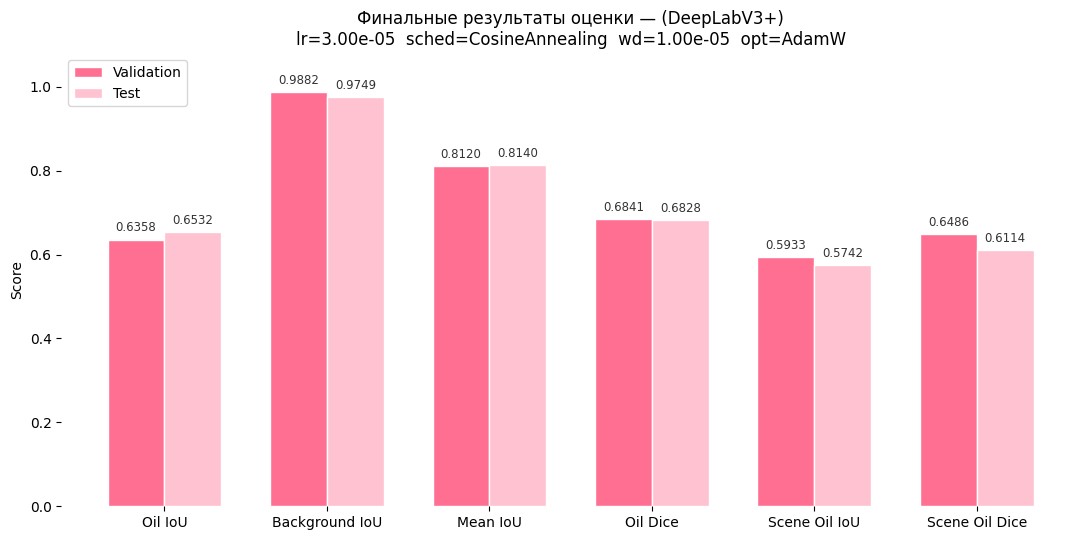

In [41]:
import numpy as np
import matplotlib.pyplot as plt

metrics_labels = [
    'Oil IoU',
    'Background IoU',
    'Mean IoU',
    'Oil Dice',
    'Scene Oil IoU',
    'Scene Oil Dice'
]

val_values = [
    0.6358,  # val_oil_iou
    0.9882,  # val_background_iou
    0.8120,  # val_mean_iou
    0.6841,  # val_oil_dice
    0.5933,  # val_scene_oil_iou
    0.6486   # val_scene_oil_dice
]

test_values = [
    0.6532,  # test_oil_iou
    0.9749,  # test_background_iou
    0.8140,  # test_mean_iou
    0.6828,  # test_oil_dice
    0.5742,  # test_scene_oil_iou
    0.6114   # test_scene_oil_dice
]

FINAL_BACKBONE = 'DeepLabV3+'
WINNER_CONFIG = dict(
    LR=3e-5,
    SCHEDULER='CosineAnnealing',
    WEIGHT_DECAY=1e-5,
    OPTIMIZER='AdamW'
)

C_PINK = '#FF6F91'
C_PINK_SOFT = '#FFC2D1'
C_GRAY_DARK = '#333333'

x = np.arange(len(metrics_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5.5))

bars_val  = ax.bar(x - width/2, val_values,  width, color=C_PINK,      edgecolor='white', label='Validation', zorder=3)
bars_test = ax.bar(x + width/2, test_values, width, color=C_PINK_SOFT, edgecolor='white', label='Test',       zorder=3)

for bars in (bars_val, bars_test):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.012,
            f'{height:.4f}',
            ha='center',
            va='bottom',
            fontsize=8.5,
            color=C_GRAY_DARK
        )

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)

ax.set_title(
    f'Финальные результаты оценки — ({FINAL_BACKBONE})\n'
    f'lr={WINNER_CONFIG["LR"]:.2e}  '
    f'sched={WINNER_CONFIG["SCHEDULER"]}  '
    f'wd={WINNER_CONFIG["WEIGHT_DECAY"]:.2e}  '
    f'opt={WINNER_CONFIG["OPTIMIZER"]}',
    fontsize=12
)

ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.savefig('final_summary_metrics_deeplab.png')
plt.show()

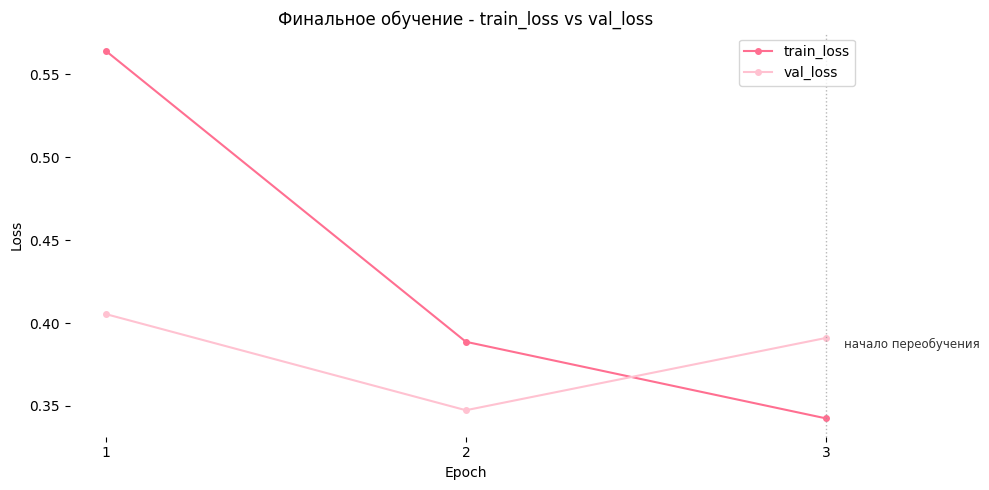

In [42]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]

train_loss = [0.5642, 0.3887, 0.3425]
val_loss   = [0.4054, 0.3474, 0.3910]

C_PINK = '#FF6F91'
C_PINK_SOFT = '#FFC2D1'
C_GRAY = '#999999'
C_GRAY_DARK = '#333333'

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, train_loss, color=C_PINK,      marker='o', markersize=4, label='train_loss')
ax.plot(epochs, val_loss,   color=C_PINK_SOFT, marker='o', markersize=4, label='val_loss')

ax.axvline(3, color=C_GRAY, linewidth=1.0, linestyle=':', alpha=0.7)
ax.text(3.05, max(val_loss) * 0.95, 'начало переобучения', fontsize=8.5, color=C_GRAY_DARK)

ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Финальное обучение - train_loss vs val_loss')
ax.set_xticks([1, 2, 3])
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.savefig('final_train_val_loss_deeplab.png')
plt.show()

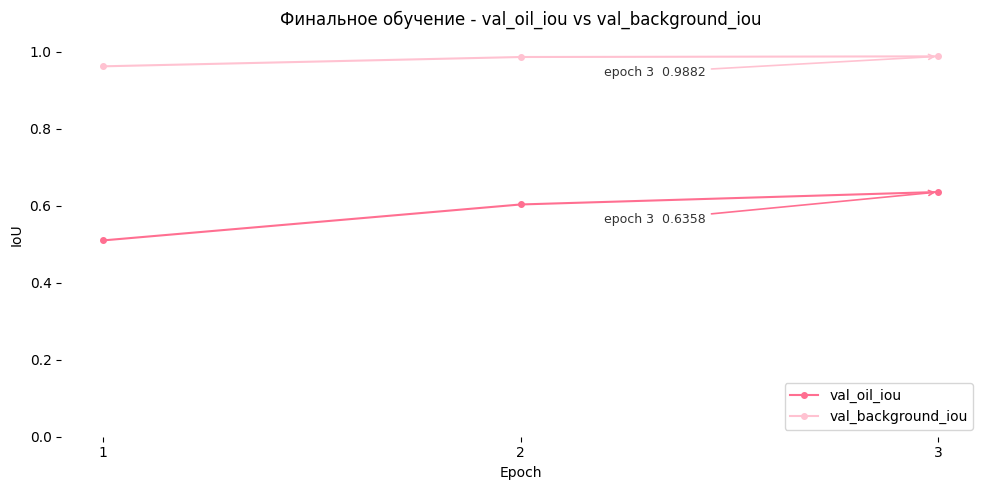

In [43]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3]

val_oil_iou = [0.5100, 0.6034, 0.6358]
val_bg_iou  = [0.9623, 0.9865, 0.9882]

C_PINK = '#FF6F91'
C_PINK_SOFT = '#FFC2D1'
C_DARK = '#333333'

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(epochs, val_oil_iou, color=C_PINK,      marker='o', markersize=4, label='val_oil_iou')
ax.plot(epochs, val_bg_iou,  color=C_PINK_SOFT, marker='o', markersize=4, label='val_background_iou')

best_epoch_oil = val_oil_iou.index(max(val_oil_iou)) + 1
best_val_oil   = max(val_oil_iou)
ax.annotate(
    f'epoch {best_epoch_oil}  {best_val_oil:.4f}',
    xy=(best_epoch_oil, best_val_oil),
    xytext=(best_epoch_oil - 0.8, best_val_oil - 0.08),
    arrowprops=dict(arrowstyle='->', color=C_PINK, lw=1.2),
    fontsize=9, color=C_DARK
)

best_epoch_bg = val_bg_iou.index(max(val_bg_iou)) + 1
best_val_bg   = max(val_bg_iou)
ax.annotate(
    f'epoch {best_epoch_bg}  {best_val_bg:.4f}',
    xy=(best_epoch_bg, best_val_bg),
    xytext=(best_epoch_bg - 0.8, best_val_bg - 0.05),
    arrowprops=dict(arrowstyle='->', color=C_PINK_SOFT, lw=1.2),
    fontsize=9, color=C_DARK
)

ax.set_xlabel('Epoch')
ax.set_ylabel('IoU')
ax.set_title('Финальное обучение - val_oil_iou vs val_background_iou')
ax.set_xticks([1, 2, 3])
ax.set_ylim(0, 1.05)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('final_iou_curves_deeplab.png')
plt.show()

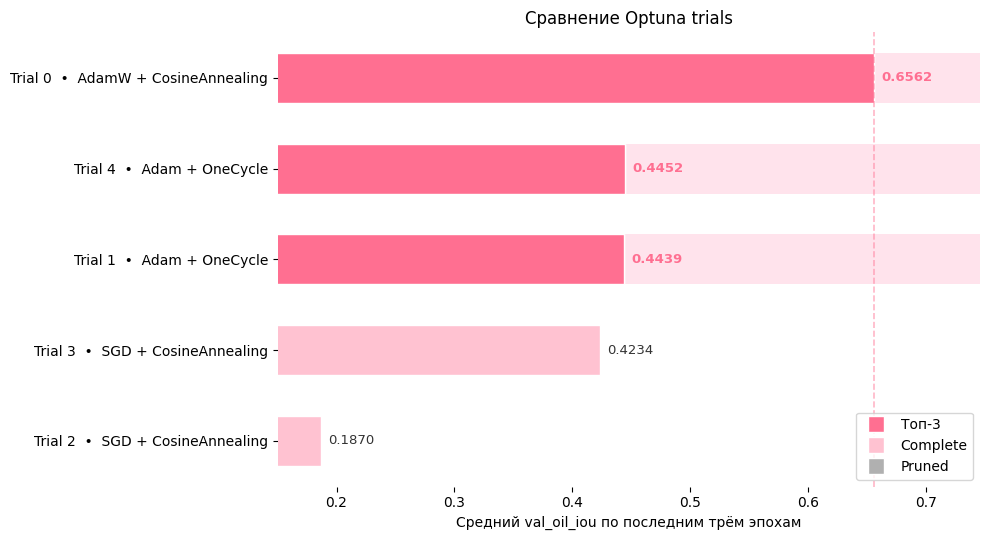

In [44]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

trials_data = [
    (0, 'AdamW', 'CosineAnnealing', 0.6562, 'complete'),
    (1, 'Adam',  'OneCycle',        0.4439, 'complete'),
    (2, 'SGD',   'CosineAnnealing', 0.1870, 'complete'),
    (3, 'SGD',   'CosineAnnealing', 0.4234, 'complete'),
    (4, 'Adam',  'OneCycle',        0.4452, 'complete'),
]

trials_data_sorted = sorted(trials_data, key=lambda x: x[3])

trial_labels = [f"Trial {t[0]}  •  {t[1]} + {t[2]}" for t in trials_data_sorted]
iou_values   = [t[3] for t in trials_data_sorted]
states       = [t[4] for t in trials_data_sorted]

complete_iou = sorted(
    [(t[3], i) for i, t in enumerate(trials_data_sorted) if t[4] == 'complete'],
    reverse=True
)
top3_indices = {idx for _, idx in complete_iou[:3]}

C_PINK = '#FF6F91'
C_PINK_SOFT = '#FFC2D1'
C_GRAY = '#B0B0B0'
C_GRAY_DARK = '#333333'
C_PINK_BG = '#FFE3EC'

bar_colors = []
for i, state in enumerate(states):
    if i in top3_indices:
        bar_colors.append(C_PINK)
    elif state == 'pruned':
        bar_colors.append(C_GRAY)
    else:
        bar_colors.append(C_PINK_SOFT)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')

bars = ax.barh(
    trial_labels, iou_values,
    color=bar_colors,
    edgecolor='white',
    height=0.55,
    zorder=3
)

for i in top3_indices:
    ax.barh(
        trial_labels[i], 1.0,
        color=C_PINK_BG,
        height=0.55,
        zorder=2,
        left=0
    )
    ax.barh(
        trial_labels[i], iou_values[i],
        color=C_PINK,
        edgecolor='white',
        height=0.55,
        zorder=3
    )

for bar, val, i in zip(bars, iou_values, range(len(iou_values))):
    ax.text(
        val + 0.006,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', ha='left',
        fontsize=9.5,
        color=C_PINK if i in top3_indices else C_GRAY_DARK,
        fontweight='bold' if i in top3_indices else 'normal'
    )

best_val = max(iou_values)
ax.axvline(best_val, color=C_PINK, linewidth=1.2, linestyle='--', alpha=0.5, zorder=4)

ax.set_xlabel('Средний val_oil_iou по последним трём эпохам')
ax.set_xlim(0.15, max(iou_values) + 0.09)
ax.set_title('Сравнение Optuna trials')
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_PINK,      markersize=11, label='Топ-3'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_PINK_SOFT, markersize=11, label='Complete'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor=C_GRAY,      markersize=11, label='Pruned'),
]

ax.legend(handles=legend_elements, loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('optuna_trials_deeplab.png')
plt.show()

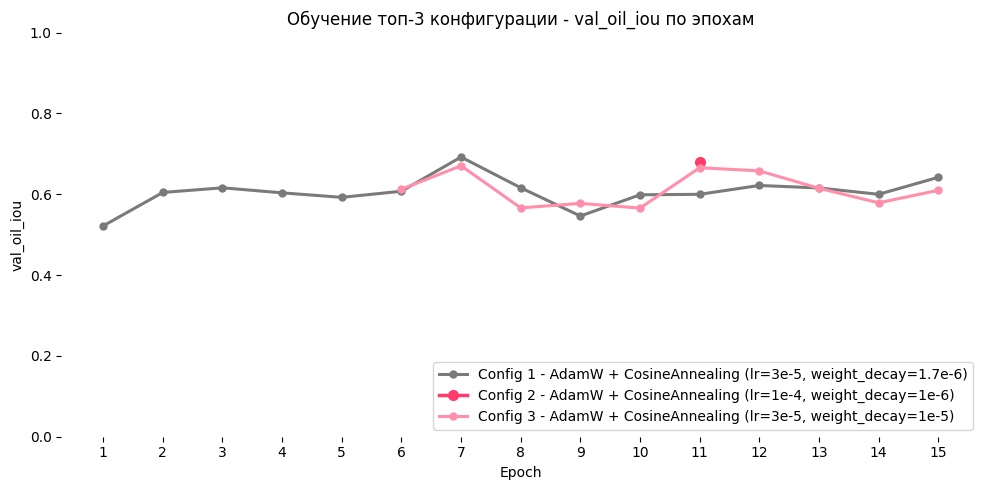

In [1]:
import matplotlib.pyplot as plt

# Конфиг #1 (trial 0)
epochs_A = list(range(1, 16))
oil_iou_A = [
    0.5217, 0.6044, 0.6159, 0.6034, 0.5923,
    0.6074, 0.6920, 0.6160, 0.5461, 0.5986,
    0.5998, 0.6217, 0.6155, 0.5998, 0.6418
]

# Конфиг #2 (trial A)
epochs_B = [11]
oil_iou_B = [0.679853]

# Конфиг #3 (trial B)
epochs_C = list(range(6, 16))
oil_iou_C = [
    0.6124, 0.6704, 0.5662, 0.5773, 0.5657,
    0.6655, 0.6579, 0.6147, 0.5788, 0.6097
]

C_GRAY = '#7A7A7A'
C_PINK = '#FF3B6B'
C_PINK_SOFT = '#FF8FAB'

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    epochs_A, oil_iou_A,
    color=C_GRAY,
    marker='o',
    markersize=5,
    linewidth=2.2,
    label='Config 1 - AdamW + CosineAnnealing (lr=3e-5, weight_decay=1.7e-6)'
)

ax.plot(
    epochs_B, oil_iou_B,
    color=C_PINK,
    marker='o',
    markersize=7,
    linewidth=2.5,
    label='Config 2 - AdamW + CosineAnnealing (lr=1e-4, weight_decay=1e-6)'
)

ax.plot(
    epochs_C, oil_iou_C,
    color=C_PINK_SOFT,
    marker='o',
    markersize=5,
    linewidth=2.2,
    label='Config 3 - AdamW + CosineAnnealing (lr=3e-5, weight_decay=1e-5)'
)

ax.set_xlabel('Epoch')
ax.set_ylabel('val_oil_iou')
ax.set_title('Обучение топ-3 конфигурации - val_oil_iou по эпохам')

ax.set_xticks(list(range(1, 16)))
ax.set_ylim(0, 1.0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig('stage2_val_oil_iou_deeplab.png', dpi=300)
plt.show()